In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set a beautiful visual theme for our charts
sns.set_theme(style="whitegrid")
print("Libraries loaded for Customer Churn Prediction!")

Libraries loaded for Customer Churn Prediction!


In [21]:
# Load the dataset
file_path = "Dataset/Churn_Modelling.csv"
ch_df = pd.read_csv(file_path)

# Dropping useless identification columns if they are present
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'customerID']
ch_df = ch_df.drop(columns=[c for c in cols_to_drop if c in ch_df.columns], errors='ignore')

# Identifying target column: 
tgt_col = 'Exited' if 'Exited' in ch_df.columns else 'Churn'

print("Data loaded and processed. Few rows for look:")
display(ch_df.head())

Data loaded and processed. Few rows for look:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# custom features
ch_df['Balance_Salary_Ratio'] = ch_df['Balance'] / (ch_df['EstimatedSalary'] + 1)
ch_df['Age_NumProducts'] = ch_df['Age'] * ch_df['NumOfProducts']
ch_df['IsActive_by_Age'] = ch_df['IsActiveMember'] / ch_df['Age']

print("Smarter features created. Current columns:")
print(ch_df.columns.tolist())

Smarter features created! Current columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Balance_Salary_Ratio', 'Age_NumProducts', 'IsActive_by_Age']


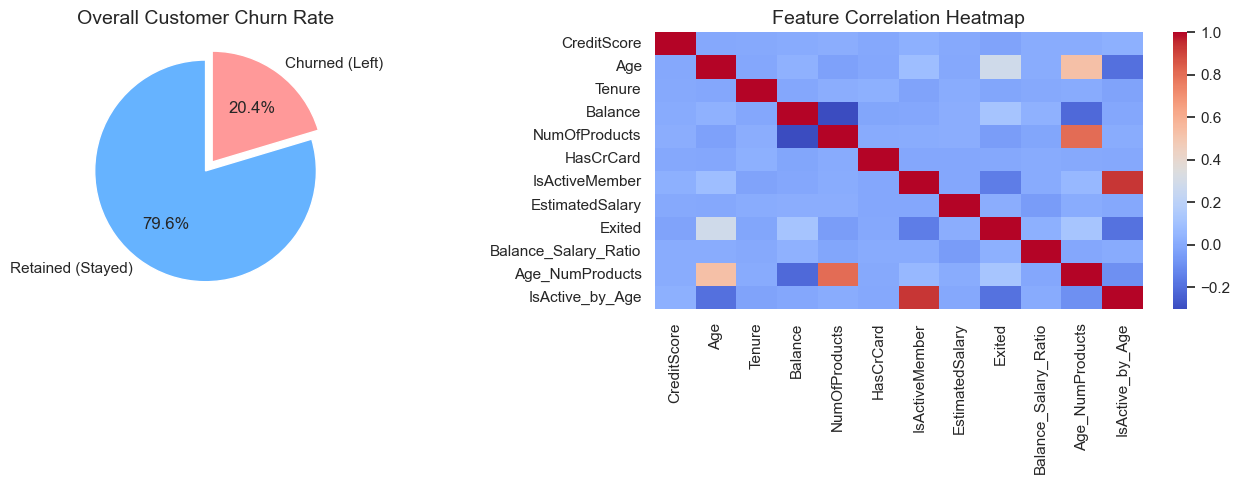

In [23]:
# EDA to understand the data
plt.figure(figsize=(14, 5))

# Chart 1:Churn Balance (Pie Chart)
plt.subplot(1, 2, 1)
churn_counts = ch_df[tgt_col].value_counts()
plt.pie(churn_counts, labels=['Retained (Stayed)', 'Churned (Left)'], 
        autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.1))
plt.title('Overall Customer Churn Rate', fontsize=14)

# Chart 2:Correlation Heatmap (Numeric data only)
plt.subplot(1, 2, 2)
num_data = ch_df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_data.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Convert text categories (Geography/Gender) to numbers
ch_df_numeric = pd.get_dummies(ch_df, drop_first=True)

# 2. Separate features (inputs) from the target (output)
tgt_col = 'Exited'
X = ch_df_numeric.drop(columns=[tgt_col])
y = ch_df_numeric[tgt_col]

# 3. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling the features so large numbers don't overpower small ones
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is split and scaled is completed.")

Data is split and scaled perfectly!


In [ ]:
# Initialize the Gradient Boosting Classifier with custom settings preferred
best_engine = GradientBoostingClassifier(
    n_estimators=150,      # No. of decision trees
    learning_rate=0.05,    # Slower but precise learning pace
    max_depth=5,           # Deepness to look into data
    subsample=0.8,         # Use 80% of data per tree to prevent memorizing answers
    random_state=42
)

print("Training the model... (this might take a few seconds)")
best_engine.fit(X_train_scaled, y_train)
print("Training complete.")

Training the optimized engine... (this might take a few seconds)
Training complete!


✅ Optimal Model Accuracy: 86.60%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  Stayed (0)       0.89      0.96      0.92      1607
 Churned (1)       0.73      0.50      0.59       393

    accuracy                           0.87      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



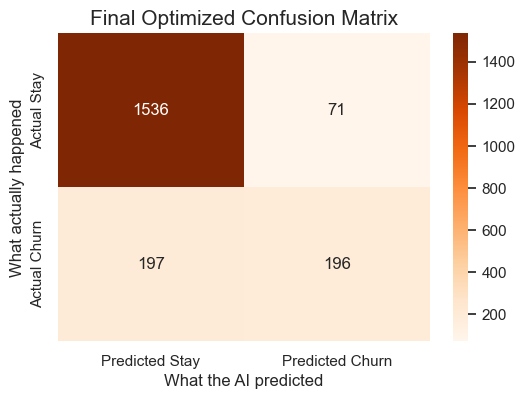

In [ ]:
# predictions on the hidden test set
preds = best_engine.predict(X_test_scaled)

# Calculate and print metrics
acc = accuracy_score(y_test, preds) * 100
print(f"✅ Optimal Model Accuracy: {acc:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, preds, target_names=['Stayed (0)', 'Churned (1)']))

# Draw the Confusion Matrix
plt.figure(figsize=(6, 4))
c_mat = confusion_matrix(y_test, preds)
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'])

plt.title('Final Optimized Confusion Matrix', fontsize=15)
plt.ylabel('What actually happened')
plt.xlabel('What the AI predicted')
plt.show()